# 05 · Cross-Persona Convergence Analysis

Integrates outputs from notebooks 02–04 to produce a unified view of how much personas **converge** across three dimensions:

| Dimension | Measure |
|-----------|------|
| **Label** | Pairwise label agreement (Jaccard on perception tags) per image |
| **Sentiment** | Pairwise agreement on `predicted_sentiment` per image |
| **Caption text** | Mean cosine similarity of caption embeddings per image |

**Goal**: Identify which dimension shows the most divergence, and whether persona characteristics (demographics) explain divergence patterns.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.config import FIGURES, OUTPUTS, FONT_SCALE, SENT_COLORS, SENT_COLORS_3
from src.data_loading import load_annotations, parse_demographics, create_profiles
from src.convergence import compute_sentiment_agreement, compute_label_jaccard, merge_convergence_dimensions

MUTED = sns.color_palette("muted")
sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

FIGURES.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

df = load_annotations()
df = parse_demographics(df)
df = create_profiles(df)
print(f"Records: {len(df):,} | Images: {df['image_id'].nunique():,} | Personas: {df['persona_id'].nunique():,}")

Records: 59,708


## 1 · Load pre-computed similarity from notebook 03

In [2]:
sim_df = pd.read_csv(OUTPUTS / "per_image_cosine_similarity.csv")
sim_df = sim_df.rename(columns={"mean_sim": "caption_sim"})
print(f"Image-level caption similarity: {len(sim_df):,} images")

Image-level caption similarity: 50 images


## 2 · Compute per-image sentiment agreement

In [3]:
sent_agree_df = compute_sentiment_agreement(df)
print(f"Sentiment agreement computed for {len(sent_agree_df):,} images")
sent_agree_df.describe().round(4)

Sentiment agreement:   0%|          | 0/50 [00:00<?, ?it/s]

Sentiment agreement — mean: 0.759


## 3 · Compute per-image perception label agreement (Jaccard)

In [4]:
label_agree_df = compute_label_jaccard(df)
print(f"Label Jaccard computed for {len(label_agree_df):,} images")
label_agree_df.describe().round(4)

Label agreement:   0%|          | 0/50 [00:00<?, ?it/s]

Label Jaccard — mean: 0.437


## 4 · Merge all three dimensions

In [5]:
conv_df = (
    sim_df[["image_id", "caption_sim", "n_personas"]]
    .merge(sent_agree_df[["image_id", "sentiment_agreement", "majority_sentiment"]], on="image_id")
    .merge(label_agree_df, on="image_id")
)
conv_df.to_csv(OUTPUTS / "convergence_all_dimensions.csv", index=False)
print(f"Convergence dataframe: {conv_df.shape}")
conv_df.describe().round(4)

Convergence dataframe: (50, 6)


,caption_sim,n_personas,sentiment_agreement,label_jaccard
count,50.0000,50.0000,50.0000,50.0000
mean,0.8727,1194.1600,0.7589,0.4370
std,0.0734,26.8939,0.2515,0.1501
min,0.6337,1015.0000,0.3163,0.1407
25%,0.8356,1199.0000,0.5122,0.3443
50%,0.8753,1200.0000,0.8772,0.4170
75%,0.9250,1200.0000,0.9913,0.5235
max,0.9798,1200.0000,1.0000,0.8217


## 5 · Radar / spider chart — mean convergence per dimension

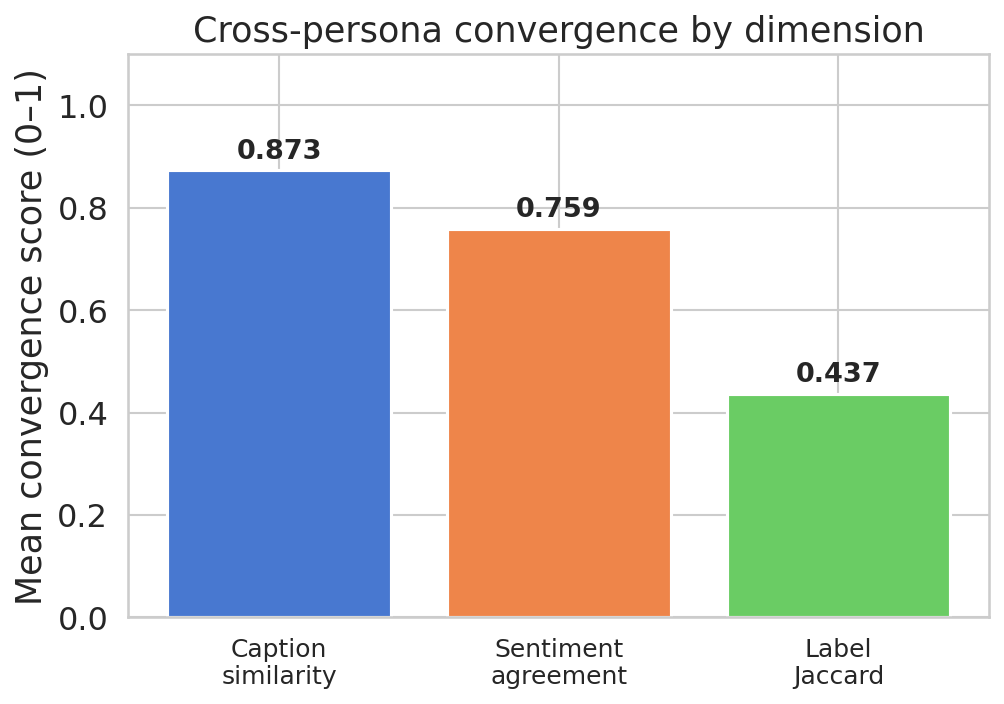

In [6]:
dims = ["Caption\nsimilarity", "Sentiment\nagreement", "Label\nJaccard"]
values = [
    conv_df["caption_sim"].mean(),
    conv_df["sentiment_agreement"].mean(),
    conv_df["label_jaccard"].mean(),
]

fig, ax = plt.subplots(figsize=(7, 5))
dim_colors = [MUTED[0], MUTED[1], MUTED[2]]
bars = ax.bar(dims, values, color=dim_colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 0.012,
        f"{val:.3f}", ha="center", va="bottom", fontsize=13, fontweight="bold",
    )
ax.set_ylim(0, 1.1)
ax.set_ylabel("Mean convergence score (0–1)")
# ax.set_title("Cross-persona convergence by dimension")
ax.tick_params(axis="x", rotation=0, labelsize=12)
plt.tight_layout()
fig.savefig(FIGURES / "fig_convergence_by_dimension.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_convergence_by_dimension.png", bbox_inches="tight")
plt.show()


## 6 · Pairwise scatter — caption similarity vs. sentiment agreement

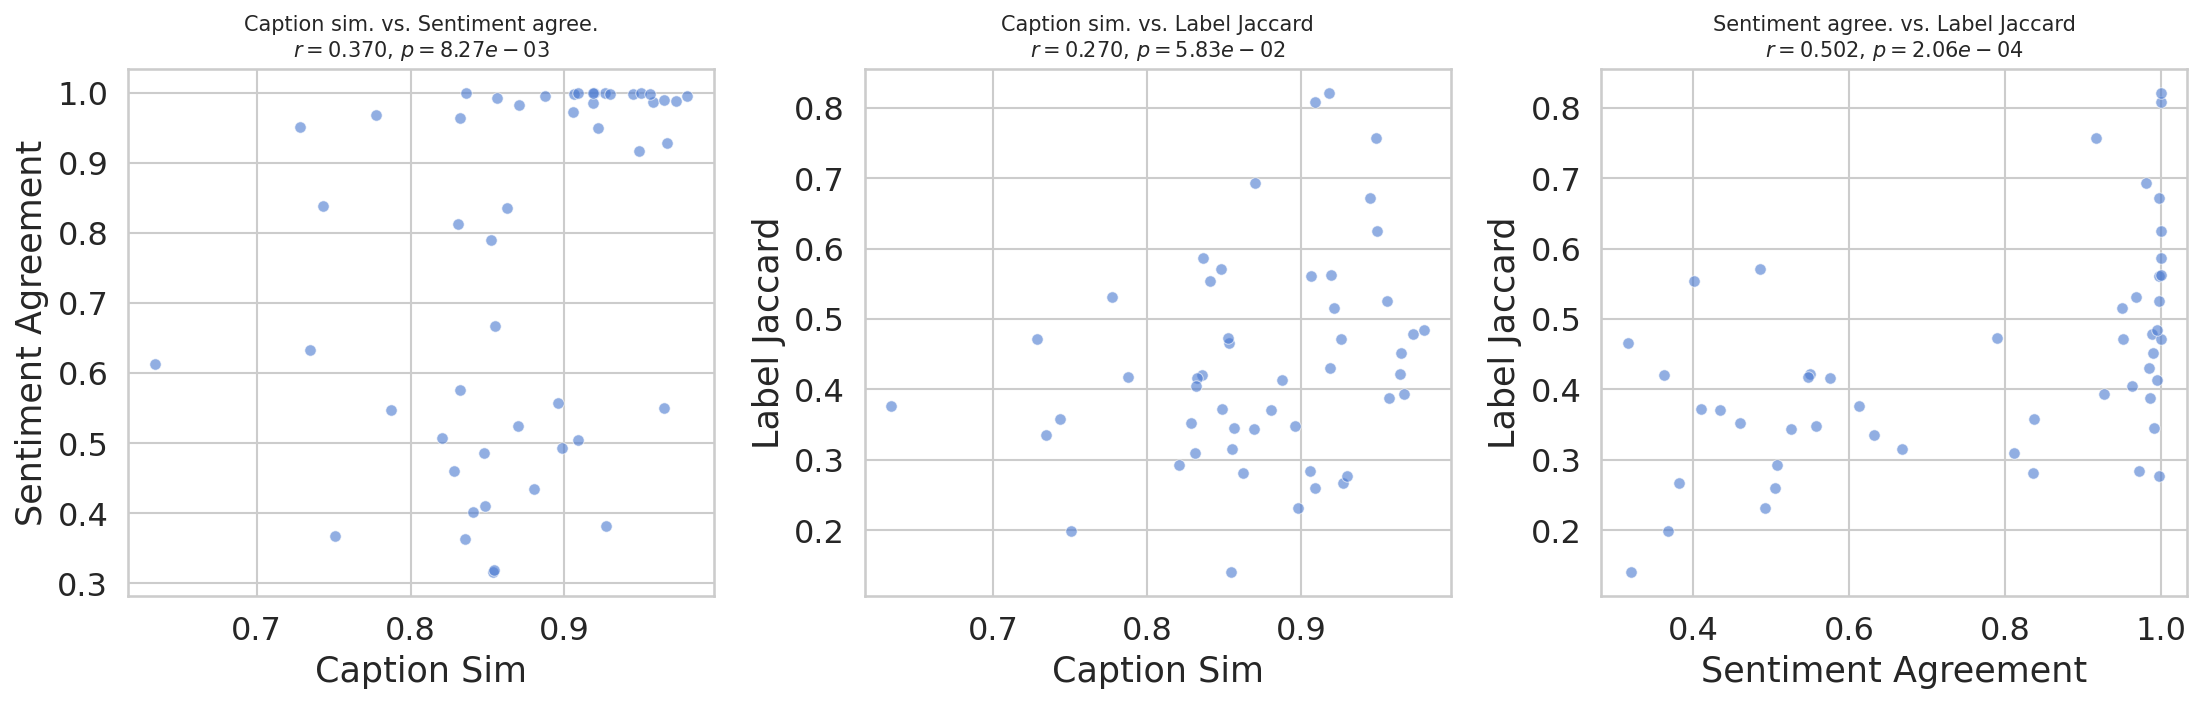

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    ("caption_sim", "sentiment_agreement", "Caption sim. vs. Sentiment agree."),
    ("caption_sim", "label_jaccard",        "Caption sim. vs. Label Jaccard"),
    ("sentiment_agreement", "label_jaccard", "Sentiment agree. vs. Label Jaccard"),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(conv_df[x], conv_df[y], alpha=0.6, s=30, color=MUTED[0],
               edgecolors="white", linewidths=0.5)
    r, p = stats.pearsonr(conv_df[x], conv_df[y])
    ax.set_xlabel(x.replace("_", " ").title())
    ax.set_ylabel(y.replace("_", " ").title())
#     ax.set_title(f"{title}\n$r={r:.3f}$, $p={p:.2e}$", fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES / "fig_convergence_pairwise_scatter.pdf")
fig.savefig(FIGURES / "fig_convergence_pairwise_scatter.png")
plt.show()


## 7 · Convergence by majority sentiment

/tmp/ipykernel_88292/11358244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="majority_sentiment", y=col, order=order,
/tmp/ipykernel_88292/11358244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="majority_sentiment", y=col, order=order,
/tmp/ipykernel_88292/11358244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="majority_sentiment", y=col, order=order,


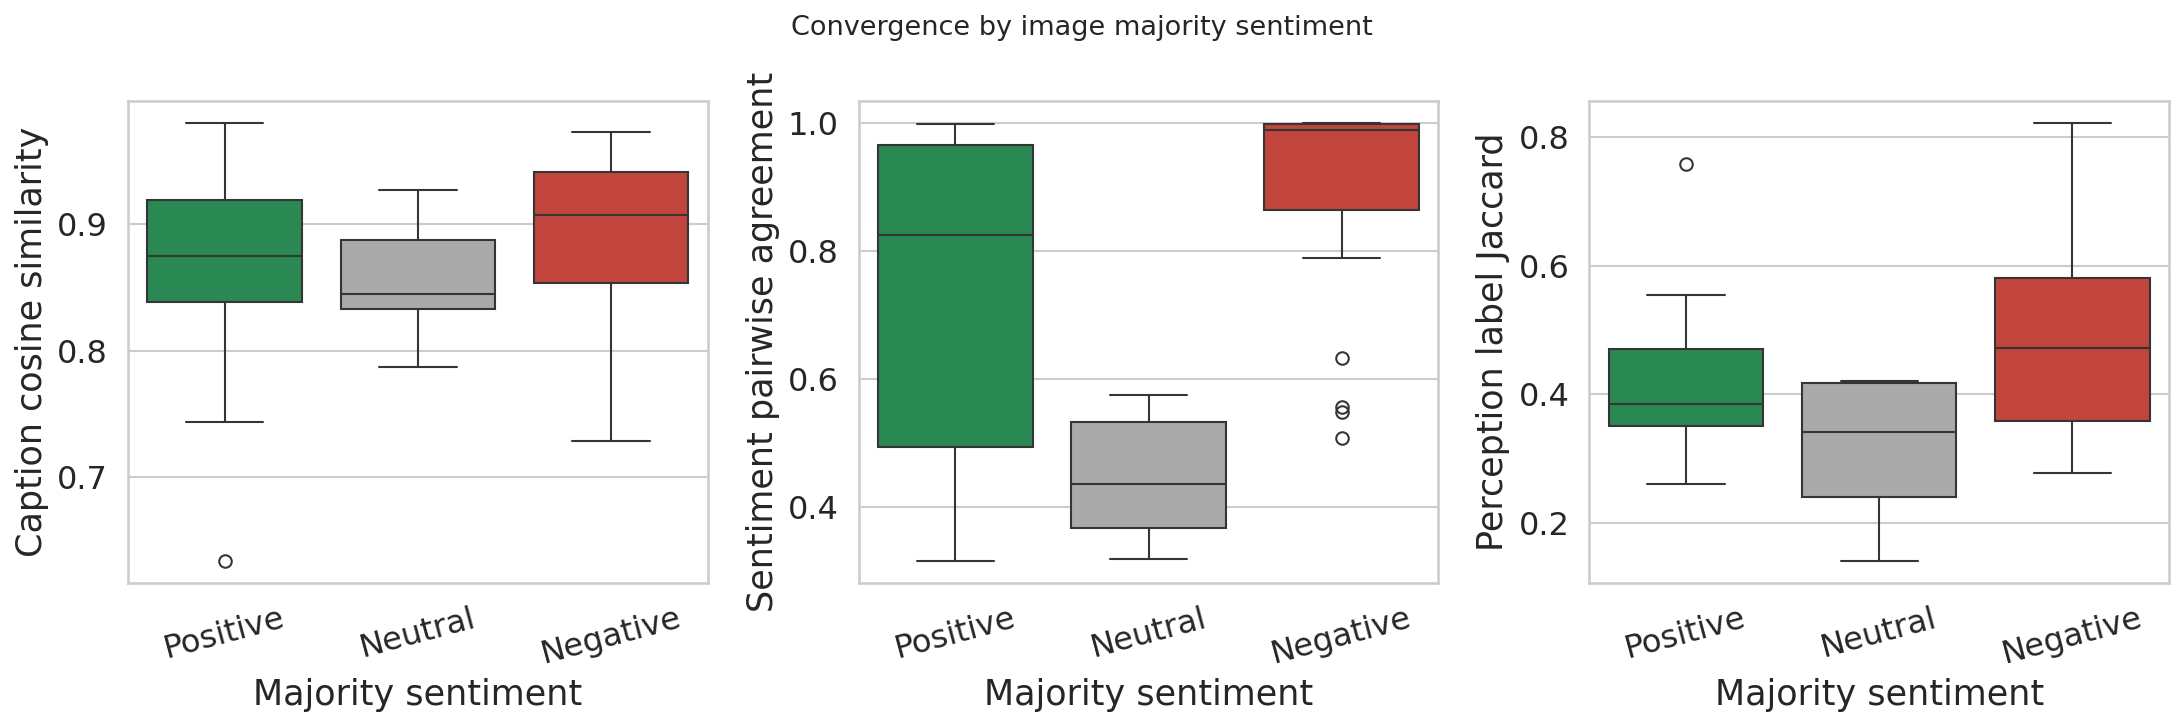

In [8]:
order = ["Positive", "Neutral", "Negative"]
sub = conv_df[conv_df["majority_sentiment"].isin(order)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bp_palette = [SENT_COLORS_3[s] for s in order]
for ax, col, ylabel in zip(
    axes,
    ["caption_sim", "sentiment_agreement", "label_jaccard"],
    ["Caption cosine similarity", "Sentiment pairwise agreement", "Perception label Jaccard"]
):
    sns.boxplot(data=sub, x="majority_sentiment", y=col, order=order,
                palette=bp_palette, ax=ax)
    ax.set_xlabel("Majority sentiment")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)

# plt.suptitle("Convergence by image majority sentiment", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "fig_convergence_by_sentiment.pdf")
fig.savefig(FIGURES / "fig_convergence_by_sentiment.png")
plt.show()


## 8 · Kruskal-Wallis test across sentiment groups

In [9]:
results = []
for col in ["caption_sim", "sentiment_agreement", "label_jaccard"]:
    groups = [sub[sub["majority_sentiment"] == s][col].dropna() for s in order]
    stat, p = stats.kruskal(*groups)
    results.append({"dimension": col, "H_statistic": stat, "p_value": p})
    print(f"{col}: H={stat:.4f}, p={p:.4e}")

pd.DataFrame(results).to_csv(OUTPUTS / "kruskal_wallis_convergence.csv", index=False)

caption_sim: H=1.8957, p=3.8758e-01
sentiment_agreement: H=17.7556, p=1.3945e-04
label_jaccard: H=7.0653, p=2.9227e-02


## 9 · Add justification similarity as a 4th convergence dimension

Notebook 03 (sections 8–9) now computes pairwise cosine similarity of *justification*
embeddings per image. Including this dimension shows whether persona-driven text content
(captions + justifications) diverges or converges similarly to structured outputs
(sentiment labels and perception tags).

In [ ]:
JUST_SIM_PATH = OUTPUTS / "per_image_just_similarity.csv"

if JUST_SIM_PATH.exists():
    just_sim_df = pd.read_csv(JUST_SIM_PATH)
    just_sim_df = just_sim_df.rename(columns={"mean_just_sim": "just_sim"})
    print(f"Loaded justification similarity: {len(just_sim_df):,} images")
    just_sim_df.describe().round(4)
else:
    print("Run notebook 03 sections 8+ first to generate per_image_just_similarity.csv")
    just_sim_df = None


In [ ]:
if just_sim_df is not None:
    conv4_df = conv_df.merge(
        just_sim_df[["image_id", "just_sim"]], on="image_id", how="left"
    )
    conv4_df.to_csv(OUTPUTS / "convergence_all_dimensions_4d.csv", index=False)
    print("4-dimension convergence dataframe:")
    print(conv4_df[["caption_sim", "sentiment_agreement", "label_jaccard", "just_sim"]].describe().round(4))


## 10 · Updated bar chart — 4 convergence dimensions

In [ ]:
if just_sim_df is not None:
    dims4 = [
        "Caption\nsimilarity",
        "Justification\nsimilarity",
        "Sentiment\nagreement",
        "Label\nJaccard",
    ]
    values4 = [
        conv4_df["caption_sim"].mean(),
        conv4_df["just_sim"].mean(),
        conv4_df["sentiment_agreement"].mean(),
        conv4_df["label_jaccard"].mean(),
    ]
    dim_colors4 = [MUTED[0], MUTED[2], MUTED[1], MUTED[3]]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(dims4, values4, color=dim_colors4, edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, values4):
        ax.text(
            bar.get_x() + bar.get_width() / 2, val + 0.012,
            f"{val:.3f}", ha="center", va="bottom", fontsize=13, fontweight="bold",
        )
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Mean convergence score (0–1)")
#     ax.set_title("Cross-persona convergence by dimension (4D)")
    ax.tick_params(axis="x", rotation=0, labelsize=11)
    plt.tight_layout()
    fig.savefig(FIGURES / "fig_convergence_by_dimension_4d.pdf", bbox_inches="tight")
    fig.savefig(FIGURES / "fig_convergence_by_dimension_4d.png", bbox_inches="tight")
    plt.show()

    # Kruskal-Wallis over sentiment groups for all 4 dims
    order = ["Positive", "Neutral", "Negative"]
    sub4 = conv4_df[conv4_df["majority_sentiment"].isin(order)]
    print("\nKruskal-Wallis across sentiment groups (4 dimensions):")
    for col in ["caption_sim", "just_sim", "sentiment_agreement", "label_jaccard"]:
        groups = [sub4[sub4["majority_sentiment"] == s][col].dropna() for s in order]
        if all(len(g) > 1 for g in groups):
            stat, p = stats.kruskal(*groups)
            print(f"  {col:24s}: H={stat:.4f}, p={p:.4e}")
